<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/Classical_vs_Quantum_CNN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classical CNN vs Quantum CNN (Quanvolutional) – Google Colab (CPU)

Bu notebook, **klasik CNN** ile **hibrit Quantum CNN (Quanvolutional Neural Network)** modellerini Google Colab CPU runtime'ında karşılaştırır.

**Özellikler:**
- MNIST binary classification (0 vs 1)
- PennyLane ile quantum circuit simülasyonu (`default.qubit` / `lightning.qubit`)
- PyTorch entegrasyonu
- Eğitim süresi, accuracy ve loss karşılaştırması
- CPU odaklı (GPU gerekmez)

**Nasıl kullanılır:**
1. Bu dosyayı Google Colab'a yükleyin (File → Upload notebook)
2. Runtime → Change runtime type → **CPU** seçin
3. Hücreleri sırayla çalıştırın

**Not:** Quantum simülasyon CPU'da yavaştır. Küçük veri seti (500 train / 200 test) ile başlanmıştır.

## 1. Kurulum

In [ ]:
# Gerekli paketler
!pip install -q pennylane pennylane-lightning torch torchvision matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
import time
import copy

# CPU zorunlu
device = torch.device("cpu")
print("Device:", device)
print("PyTorch version:", torch.__version__)
print("PennyLane version:", qml.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.7 MB/s eta 0:00:00
Device: cpu
PyTorch version: 2.11.0+cpu
PennyLane version: 0.45.1


## 2. Veri Hazırlığı (MNIST – 0 vs 1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def filter_01(dataset):
    idx = [i for i, (_, label) in enumerate(dataset) if label in [0, 1]]
    return Subset(dataset, idx)

train_01 = filter_01(train_set)
test_01  = filter_01(test_set)

# CPU + quantum simülasyon için küçük subset
N_TRAIN = 400
N_TEST  = 150
BATCH_SIZE = 16

train_loader = DataLoader(Subset(train_01, range(N_TRAIN)), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(Subset(test_01,  range(N_TEST)),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {N_TRAIN}")
print(f"Test samples : {N_TEST}")
print(f"Batch size   : {BATCH_SIZE}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]


Train samples: 400
Test samples : 150
Batch size   : 16


## 3. Classical CNN Modeli

In [ ]:
class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

classical_model = ClassicalCNN().to(device)
n_params_classical = sum(p.numel() for p in classical_model.parameters() if p.requires_grad)
print(f"Classical CNN trainable parameters: {n_params_classical:,}")
print(classical_model)

Classical CNN trainable parameters: 105,346
ClassicalCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 4. Quantum Circuit ve Hybrid Quantum CNN

Burada **Quanvolutional** yaklaşımın basitleştirilmiş hibrit versiyonu kullanılıyor:
- Klasik convolution ile özellik çıkarımı
- Quantum variational circuit (AngleEmbedding + BasicEntanglerLayers)
- Klasik fully-connected katmanlar

Bu yapı Colab CPU'da makul sürede çalışır.

In [ ]:
n_qubits = 4
n_layers = 2

# CPU simülatörü
dev = qml.device("default.qubit", wires=n_qubits)
# Daha hızlı alternatif (destekleniyorsa):
# dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """4 özellik → 4 qubit AngleEmbedding + variational layers"""
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridQCNN(nn.Module):
    """
    Hibrit model:
    1. Klasik Conv + Pool → özellik haritası
    2. AdaptiveAvgPool ile 4 özellik çıkar
    3. Quantum circuit
    4. Klasik FC sınıflandırıcı
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))   # → (B, 16, 1, 1)
        )
        self.reduce = nn.Linear(16, n_qubits)   # 16 → 4 özellik
        self.qlayer = qlayer
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = self.conv(x)                    # (B, 16, 1, 1)
        x = x.view(x.size(0), -1)           # (B, 16)
        x = self.reduce(x)                  # (B, 4)
        # Quantum circuit (her örnek için)
        q_out = self.qlayer(x)              # (B, 4)
        out = self.classifier(q_out)
        return out

hybrid_model = HybridQCNN().to(device)
n_params_hybrid = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"Hybrid QCNN trainable parameters: {n_params_hybrid:,}")
print(hybrid_model)

Hybrid QCNN trainable parameters: 1,438
HybridQCNN(
  (conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (reduce): Linear(in_features=16, out_features=4, bias=True)
  (qlayer): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 5. Eğitim ve Değerlendirme Fonksiyonları

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += data.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(target.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, test_loader, epochs=8, lr=0.01, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")
    start = time.time()

    best_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:5.1f}% | "
              f"Test Loss: {test_loss:.4f} Acc: {test_acc*100:5.1f}%")

    elapsed = time.time() - start
    print(f"\n{name} toplam eğitim süresi: {elapsed:.1f} saniye")
    print(f"En iyi test accuracy: {best_acc*100:.2f}%")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, elapsed, best_acc

## 6. Classical CNN Eğitimi

In [ ]:
classical_model = ClassicalCNN().to(device)
classical_model, hist_c, time_c, best_acc_c = run_training(
    classical_model,
    train_loader,
    test_loader,
    epochs=8,
    lr=0.001,
    name="Classical CNN"
)


  Training: Classical CNN
Epoch 01/8 | Train Loss: 0.1954 Acc:  92.8% | Test Loss: 0.0175 Acc:  98.7%
Epoch 02/8 | Train Loss: 0.0532 Acc:  98.5% | Test Loss: 0.0260 Acc:  98.7%
Epoch 03/8 | Train Loss: 0.0201 Acc:  99.5% | Test Loss: 0.0062 Acc: 100.0%
Epoch 04/8 | Train Loss: 0.0157 Acc:  99.5% | Test Loss: 0.0056 Acc: 100.0%
Epoch 05/8 | Train Loss: 0.0142 Acc:  99.8% | Test Loss: 0.0045 Acc: 100.0%
Epoch 06/8 | Train Loss: 0.0094 Acc:  99.8% | Test Loss: 0.0022 Acc: 100.0%
Epoch 07/8 | Train Loss: 0.0134 Acc:  99.8% | Test Loss: 0.0018 Acc: 100.0%
Epoch 08/8 | Train Loss: 0.0027 Acc: 100.0% | Test Loss: 0.0016 Acc: 100.0%

Classical CNN toplam eğitim süresi: 4.5 saniye
En iyi test accuracy: 100.00%


## 7. Hybrid Quantum CNN Eğitimi

In [ ]:
hybrid_model = HybridQCNN().to(device)
hybrid_model, hist_q, time_q, best_acc_q = run_training(
    hybrid_model,
    train_loader,
    test_loader,
    epochs=8,
    lr=0.005,
    name="Hybrid Quantum CNN"
)


  Training: Hybrid Quantum CNN
Epoch 01/8 | Train Loss: 0.6301 Acc:  66.8% | Test Loss: 0.5172 Acc:  91.3%
Epoch 02/8 | Train Loss: 0.3805 Acc:  91.5% | Test Loss: 0.2392 Acc:  95.3%
Epoch 03/8 | Train Loss: 0.1947 Acc:  95.2% | Test Loss: 0.1036 Acc:  97.3%
Epoch 04/8 | Train Loss: 0.0993 Acc:  97.2% | Test Loss: 0.0666 Acc:  98.7%
Epoch 05/8 | Train Loss: 0.0771 Acc:  97.8% | Test Loss: 0.0812 Acc:  97.3%
Epoch 06/8 | Train Loss: 0.0730 Acc:  97.5% | Test Loss: 0.1119 Acc:  96.0%
Epoch 07/8 | Train Loss: 0.0949 Acc:  96.8% | Test Loss: 0.0485 Acc:  98.7%
Epoch 08/8 | Train Loss: 0.0619 Acc:  98.0% | Test Loss: 0.0472 Acc:  98.0%

Hybrid Quantum CNN toplam eğitim süresi: 6.1 saniye
En iyi test accuracy: 98.67%


## 8. Sonuçların Karşılaştırılması

In [ ]:
print("\n" + "="*60)
print("  SONUÇ ÖZETİ")
print("="*60)
print(f"{'Model':<25} {'Params':>10} {'Best Acc':>12} {'Time (s)':>10}")
print("-"*60)
print(f"{'Classical CNN':<25} {n_params_classical:>10,} {best_acc_c*100:>11.2f}% {time_c:>10.1f}")
print(f"{'Hybrid Quantum CNN':<25} {n_params_hybrid:>10,} {best_acc_q*100:>11.2f}% {time_q:>10.1f}")
print("="*60)

# Detaylı classification report
print("\n--- Classical CNN Test Report ---")
_, _, preds_c, labels_c = evaluate(classical_model, test_loader, nn.CrossEntropyLoss())
print(classification_report(labels_c, preds_c, target_names=["0", "1"]))

print("\n--- Hybrid Quantum CNN Test Report ---")
_, _, preds_q, labels_q = evaluate(hybrid_model, test_loader, nn.CrossEntropyLoss())
print(classification_report(labels_q, preds_q, target_names=["0", "1"]))


  SONUÇ ÖZETİ
Model                         Params     Best Acc   Time (s)
------------------------------------------------------------
Classical CNN                105,346      100.00%        4.5
Hybrid Quantum CNN             1,438       98.67%        6.1

--- Classical CNN Test Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        86

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


--- Hybrid Quantum CNN Test Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99        86

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



## 9. Grafikler

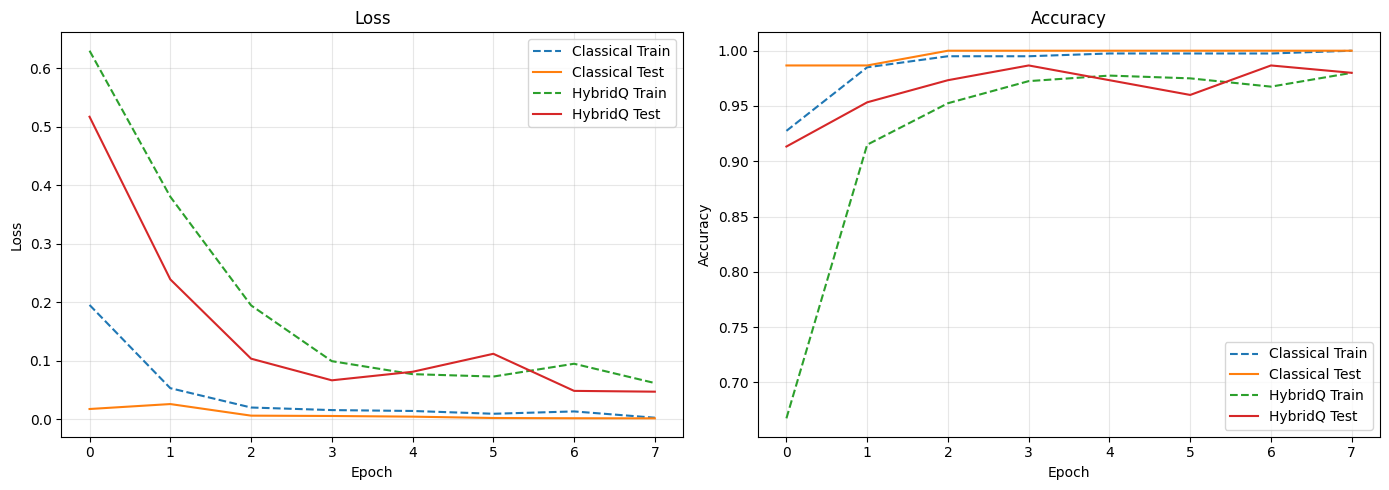

Grafik kaydedildi: classical_vs_quantum_cnn_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(hist_c["train_loss"], label="Classical Train", linestyle="--")
axes[0].plot(hist_c["test_loss"],  label="Classical Test")
axes[0].plot(hist_q["train_loss"], label="HybridQ Train", linestyle="--")
axes[0].plot(hist_q["test_loss"],  label="HybridQ Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(hist_c["train_acc"], label="Classical Train", linestyle="--")
axes[1].plot(hist_c["test_acc"],  label="Classical Test")
axes[1].plot(hist_q["train_acc"], label="HybridQ Train", linestyle="--")
axes[1].plot(hist_q["test_acc"],  label="HybridQ Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("classical_vs_quantum_cnn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: classical_vs_quantum_cnn_comparison.png")

## 10. Quantum Circuit Görselleştirme (opsiyonel)

/tmp/ipykernel_5755/358705686.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


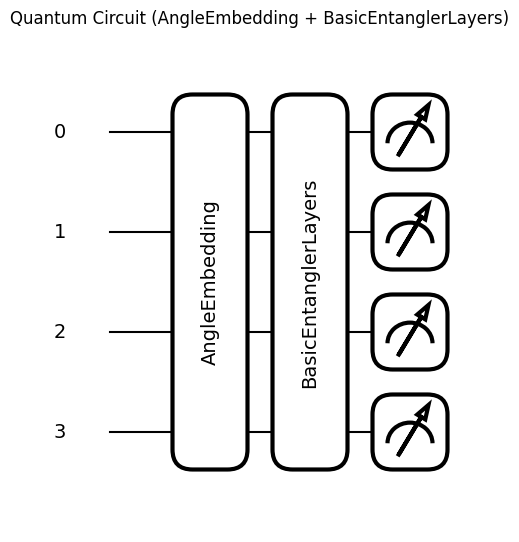

Circuit görseli kaydedildi: quantum_circuit.png


In [ ]:
# Örnek bir circuit çizimi
dummy_input = torch.randn(4)
dummy_weights = torch.randn(n_layers, n_qubits)

fig, ax = qml.draw_mpl(quantum_circuit)(dummy_input, dummy_weights)
plt.title("Quantum Circuit (AngleEmbedding + BasicEntanglerLayers)")
plt.tight_layout()
plt.savefig("quantum_circuit.png", dpi=120, bbox_inches="tight")
plt.show()
print("Circuit görseli kaydedildi: quantum_circuit.png")

## Notlar ve İpuçları

| Konu | Açıklama |
|------|----------|
| **Hız** | Quantum simülasyon CPU'da yavaştır. `N_TRAIN` ve `epochs` değerlerini artırırken dikkat edin. |
| **lightning.qubit** | Daha hızlı simülasyon için `dev = qml.device("lightning.qubit", wires=n_qubits)` deneyebilirsiniz. |
| **Gerçek quantum avantajı** | Bu örnek simülasyondur. Gerçek NISQ cihazlarında gürültü ve qubit sayısı sınırlamaları vardır. |
| **Daha fazla veri** | `N_TRAIN = 1000`, `N_TEST = 300` gibi değerlerle deneyebilirsiniz (süre artar). |
| **Multi-class** | 0-9 sınıfları için çıktı katmanını 10'a çıkarın ve veri filtrelemeyi kaldırın. |

**Kaynaklar:**
- PennyLane Quanvolution demo: https://pennylane.ai/qml/demos/tutorial_quanvolution
- TensorFlow Quantum QCNN: https://www.tensorflow.org/quantum/tutorials/qcnn
- Cong et al. QCNN paper: https://arxiv.org/abs/1810.03787

---
Hazırlayan: Classical vs Quantum CNN Colab Notebook  
Runtime: CPU  
Tarih: 2026